In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

COLORS = {
    "no_reg": "#FF006E",
    "l1": "#3A86FF",
    "l2": "#06D6A0",
    "purple": "#8338EC",
    "orange": "#FB8500",
    "dark": "#222222",
}

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.28,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (375, 2)
X_test shape : (125, 2)
y_train shape: (375,)
y_test shape : (125,)


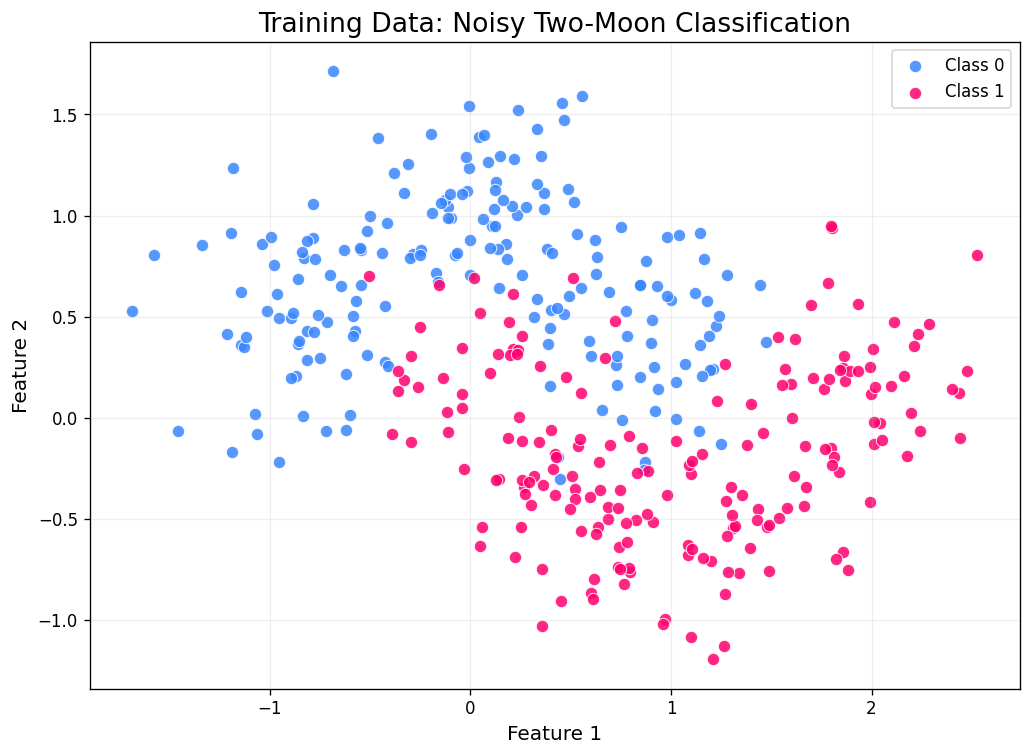

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    s=55,
    alpha=0.85,
    c="#3A86FF",
    edgecolor="white",
    linewidth=0.6,
    label="Class 0"
)

ax.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    s=55,
    alpha=0.85,
    c="#FF006E",
    edgecolor="white",
    linewidth=0.6,
    label="Class 1"
)

ax.set_title("Training Data: Noisy Two-Moon Classification")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(alpha=0.20)

plt.show()

In [4]:
def build_model(reg_type=None, lambda_value=0.0):
    """Build the same architecture with optional L1/L2 regularization."""

    if reg_type == "l1":
        regularizer = l1(lambda_value)
    elif reg_type == "l2":
        regularizer = l2(lambda_value)
    elif reg_type is None:
        regularizer = None
    else:
        raise ValueError("reg_type must be None, 'l1', or 'l2'")

    model = Sequential([
        Dense(
            128,
            input_shape=(2,),
            activation="relu",
            kernel_regularizer=regularizer
        ),
        Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizer
        ),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def all_kernel_weights(model):
    """Return all kernel weights; biases are excluded."""
    arrays = []

    for layer in model.layers:
        weights = layer.get_weights()
        if weights:
            arrays.append(weights[0].ravel())

    return np.concatenate(arrays)


def l1_weight_sum(model):
    return np.sum(np.abs(all_kernel_weights(model)))


def l2_weight_sum(model):
    return np.sum(all_kernel_weights(model) ** 2)


def near_zero_percentage(model, threshold=0.01):
    w = all_kernel_weights(model)
    return 100 * np.mean(np.abs(w) < threshold)


def evaluate_model(model, X_eval, y_eval, name):
    prob = model.predict(X_eval, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "Log Loss": log_loss(
            y_eval,
            np.clip(prob, 1e-7, 1 - 1e-7)
        ),
        "Σ|w|": l1_weight_sum(model),
        "Σw²": l2_weight_sum(model),
        "Near-zero weights (%)": near_zero_percentage(model),
    }


def plot_decision_boundary(model, X_data, y_data, ax, title):
    """Draw probability surface + 0.5 decision boundary."""
    x_min, x_max = X_data[:, 0].min() - 0.7, X_data[:, 0].max() + 0.7
    y_min, y_max = X_data[:, 1].min() - 0.7, X_data[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    prob = model.predict(grid, verbose=0).reshape(xx.shape)

    surface = ax.contourf(
        xx, yy, prob,
        levels=60,
        cmap="turbo",
        alpha=0.72
    )

    ax.contour(
        xx, yy, prob,
        levels=[0.5],
        colors="black",
        linewidths=2.2
    )

    ax.scatter(
        X_data[y_data == 0, 0],
        X_data[y_data == 0, 1],
        c="#3A86FF",
        s=25,
        edgecolor="white",
        linewidth=0.35
    )

    ax.scatter(
        X_data[y_data == 1, 0],
        X_data[y_data == 1, 1],
        c="#FF006E",
        s=25,
        edgecolor="white",
        linewidth=0.35
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.12)

    return surface

In [5]:
baseline = build_model()

history_baseline = baseline.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.25,
    verbose=0,
    shuffle=True
)

baseline.summary()
print("Baseline training completed.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,077 (199.52 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,052 (133.02 KB)

Baseline training completed.


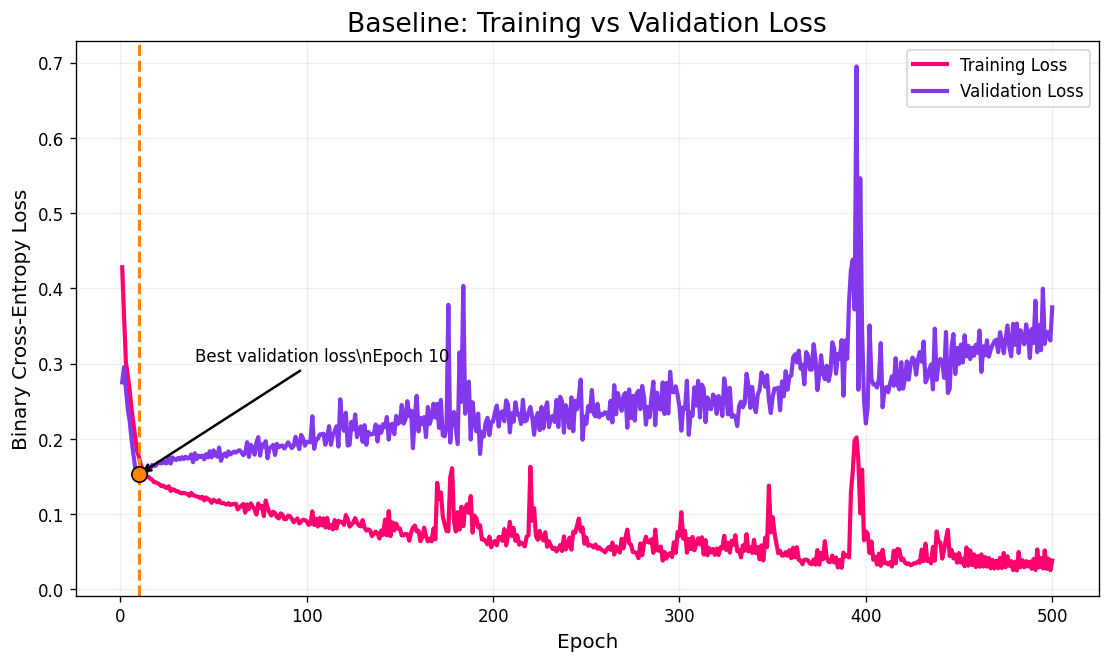

In [6]:
epochs = np.arange(1, len(history_baseline.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    epochs,
    history_baseline.history["loss"],
    color=COLORS["no_reg"],
    linewidth=2.5,
    label="Training Loss"
)

ax.plot(
    epochs,
    history_baseline.history["val_loss"],
    color=COLORS["purple"],
    linewidth=2.5,
    label="Validation Loss"
)

best_epoch = int(np.argmin(history_baseline.history["val_loss"])) + 1
best_val = np.min(history_baseline.history["val_loss"])

ax.axvline(
    best_epoch,
    color=COLORS["orange"],
    linestyle="--",
    linewidth=1.8
)

ax.scatter(
    best_epoch,
    best_val,
    s=85,
    color=COLORS["orange"],
    edgecolor="black",
    zorder=5
)

ax.annotate(
    f"Best validation loss\\nEpoch {best_epoch}",
    xy=(best_epoch, best_val),
    xytext=(best_epoch + 30, best_val + 0.15),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)

ax.set_title("Baseline: Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.legend()
ax.grid(alpha=0.20)

plt.show()

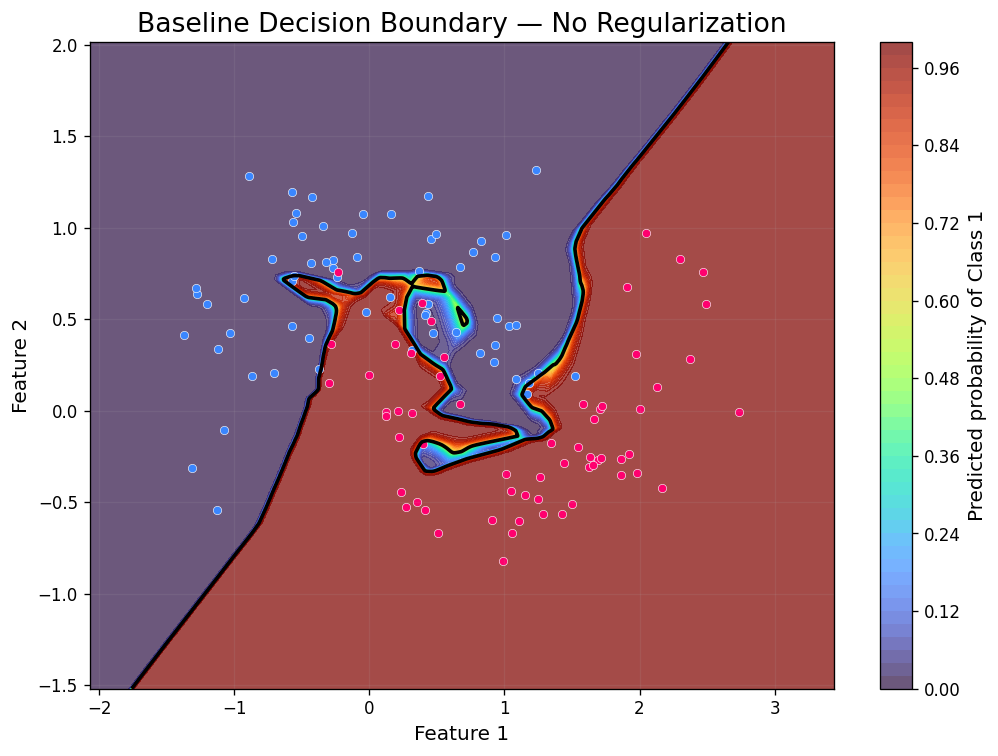

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
surface = plot_decision_boundary(
    baseline,
    X_test,
    y_test,
    ax,
    "Baseline Decision Boundary — No Regularization"
)

cbar = fig.colorbar(surface, ax=ax)
cbar.set_label("Predicted probability of Class 1")

plt.show()

In [8]:
LAMBDA_L1 = 0.001

model_l1 = build_model(
    reg_type="l1",
    lambda_value=LAMBDA_L1
)

history_l1 = model_l1.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.25,
    verbose=0,
    shuffle=True
)

print("L1 lambda:", LAMBDA_L1)

L1 lambda: 0.001


In [9]:
LAMBDA_L2 = 0.001

model_l2 = build_model(
    reg_type="l2",
    lambda_value=LAMBDA_L2
)

history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.25,
    verbose=0,
    shuffle=True
)

print("L2 lambda:", LAMBDA_L2)

L2 lambda: 0.001


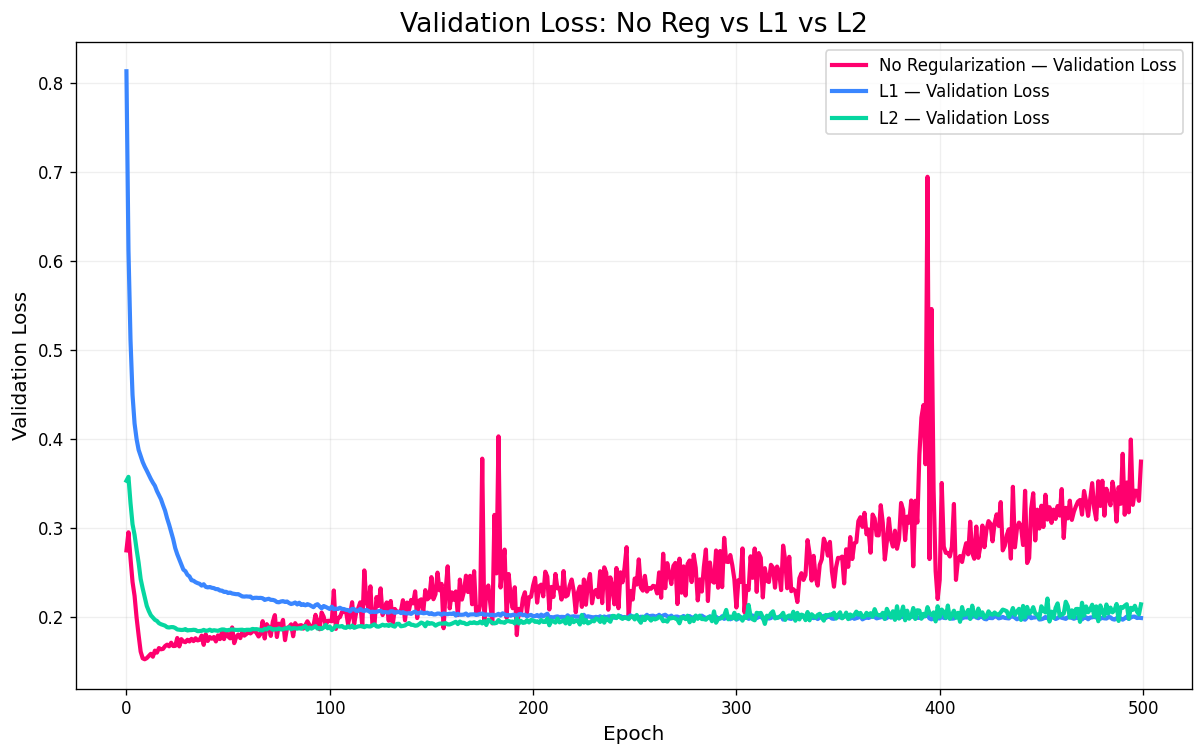

In [10]:
histories = {
    "No Regularization": (history_baseline, COLORS["no_reg"]),
    "L1": (history_l1, COLORS["l1"]),
    "L2": (history_l2, COLORS["l2"]),
}

fig, ax = plt.subplots(figsize=(12, 7))

for name, (history, color) in histories.items():
    ax.plot(
        history.history["val_loss"],
        linewidth=2.5,
        color=color,
        label=f"{name} — Validation Loss"
    )

ax.set_title("Validation Loss: No Reg vs L1 vs L2")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.legend()
ax.grid(alpha=0.20)

plt.show()

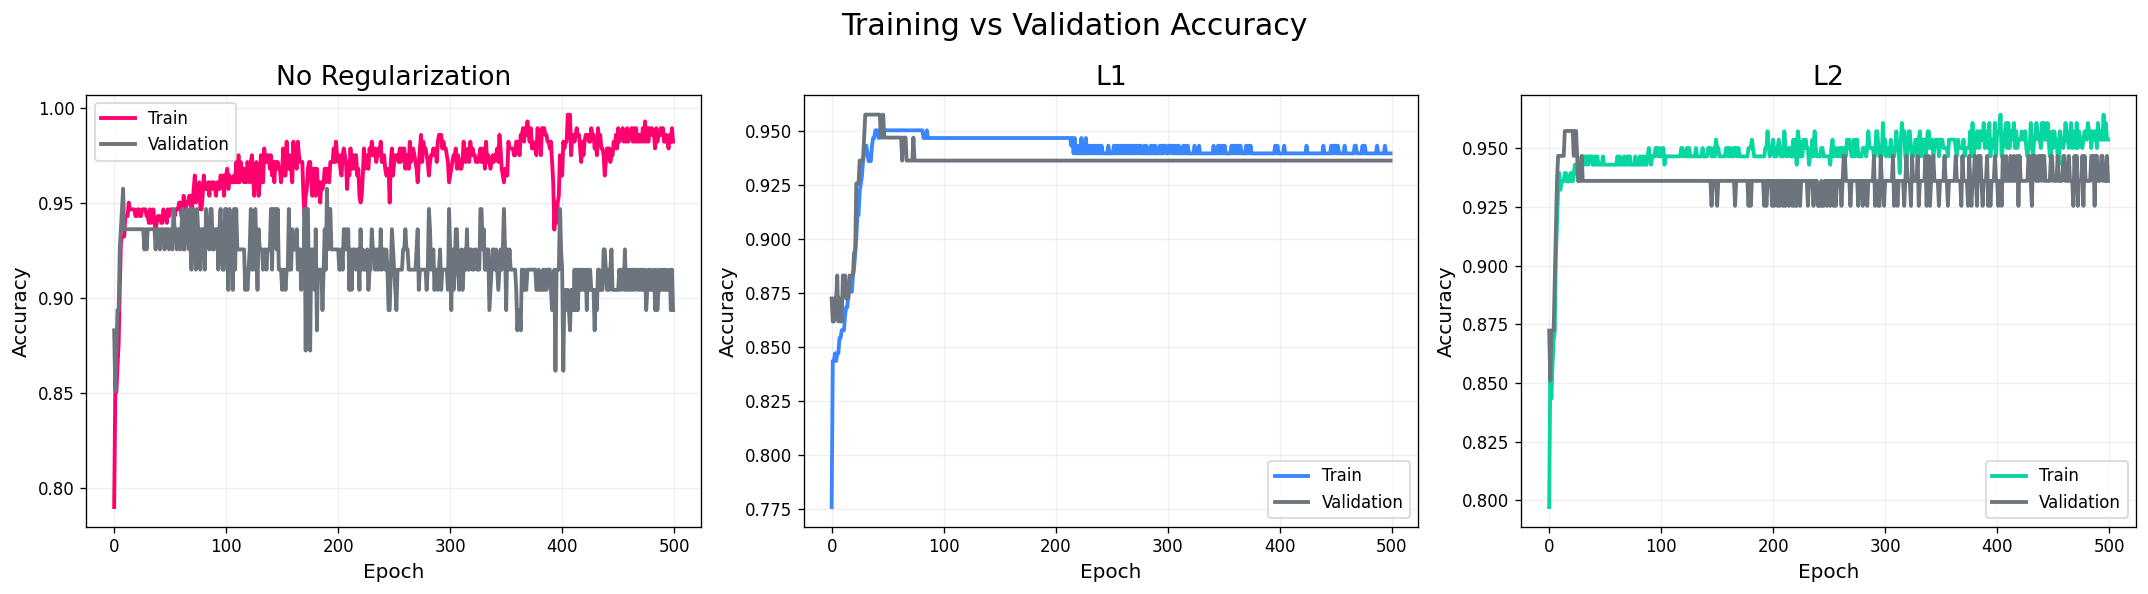

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_histories = [
    ("No Regularization", history_baseline, COLORS["no_reg"]),
    ("L1", history_l1, COLORS["l1"]),
    ("L2", history_l2, COLORS["l2"]),
]

for ax, (name, history, color) in zip(axes, models_histories):
    ax.plot(
        history.history["accuracy"],
        color=color,
        linewidth=2.3,
        label="Train"
    )
    ax.plot(
        history.history["val_accuracy"],
        color="#6C757D",
        linewidth=2.3,
        label="Validation"
    )

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.20)

fig.suptitle("Training vs Validation Accuracy", fontsize=18)
plt.tight_layout()
plt.show()

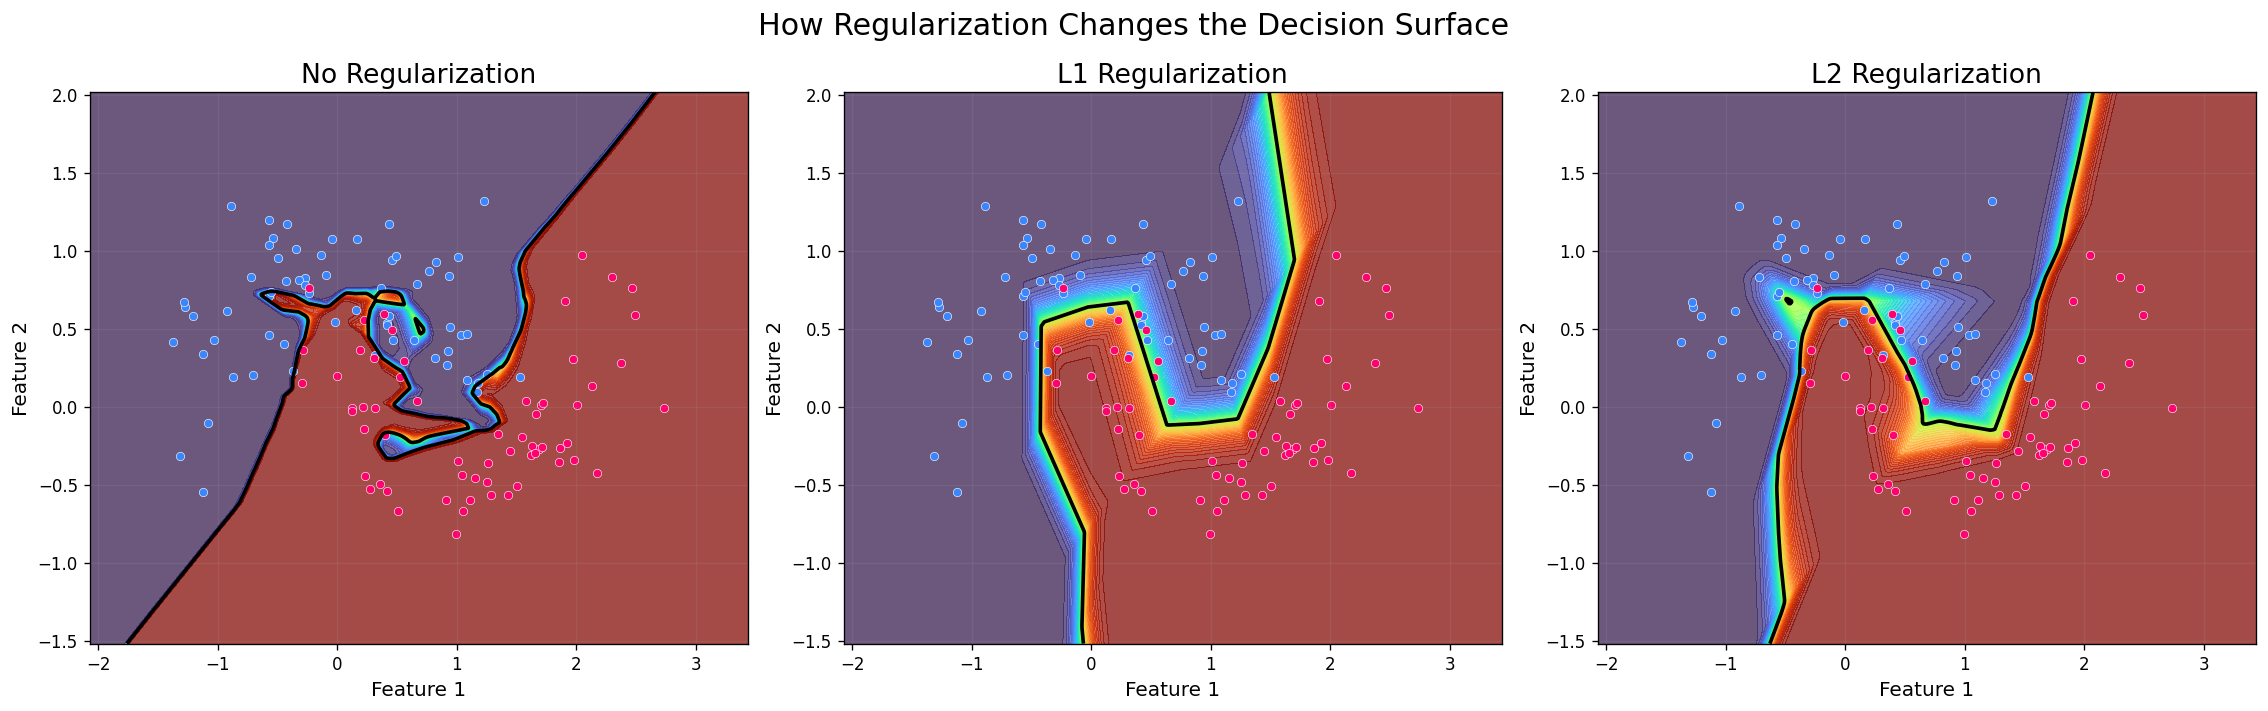

In [12]:
models = [
    ("No Regularization", baseline),
    ("L1 Regularization", model_l1),
    ("L2 Regularization", model_l2),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, (name, model) in zip(axes, models):
    surface = plot_decision_boundary(
        model,
        X_test,
        y_test,
        ax,
        name
    )

fig.suptitle("How Regularization Changes the Decision Surface", fontsize=18)
plt.tight_layout()
plt.show()

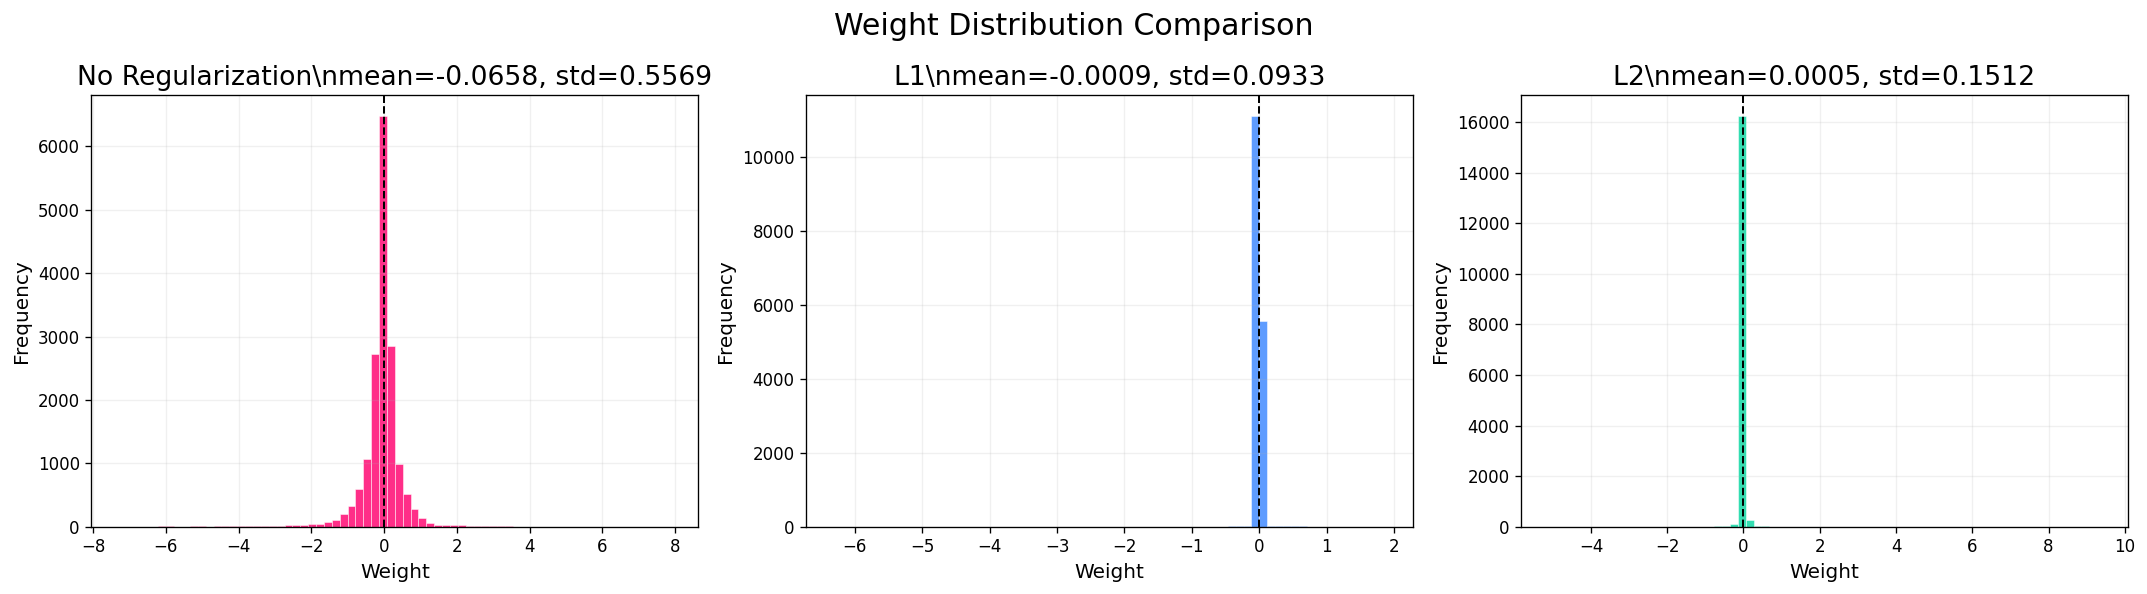

In [13]:
weight_sets = {
    "No Regularization": all_kernel_weights(baseline),
    "L1": all_kernel_weights(model_l1),
    "L2": all_kernel_weights(model_l2),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, weights) in zip(axes, weight_sets.items()):
    color = (
        COLORS["no_reg"] if name == "No Regularization"
        else COLORS["l1"] if name == "L1"
        else COLORS["l2"]
    )

    ax.hist(
        weights,
        bins=70,
        color=color,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.35
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1.2)

    ax.set_title(
        f"{name}\\nmean={weights.mean():.4f}, std={weights.std():.4f}"
    )
    ax.set_xlabel("Weight")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.18)

fig.suptitle("Weight Distribution Comparison", fontsize=18)
plt.tight_layout()
plt.show()

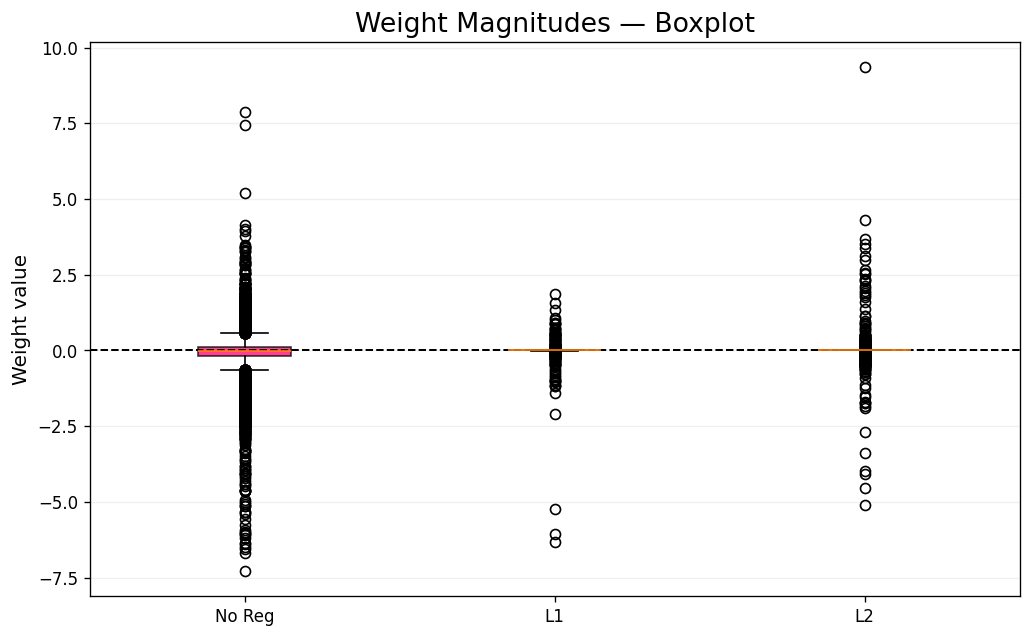

In [14]:
data = [
    weight_sets["No Regularization"],
    weight_sets["L1"],
    weight_sets["L2"],
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    data,
    labels=["No Reg", "L1", "L2"],
    patch_artist=True,
    showfliers=True
)

for patch, color in zip(
    bp["boxes"],
    [COLORS["no_reg"], COLORS["l1"], COLORS["l2"]]
):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_title("Weight Magnitudes — Boxplot")
ax.set_ylabel("Weight value")
ax.grid(axis="y", alpha=0.20)

plt.show()

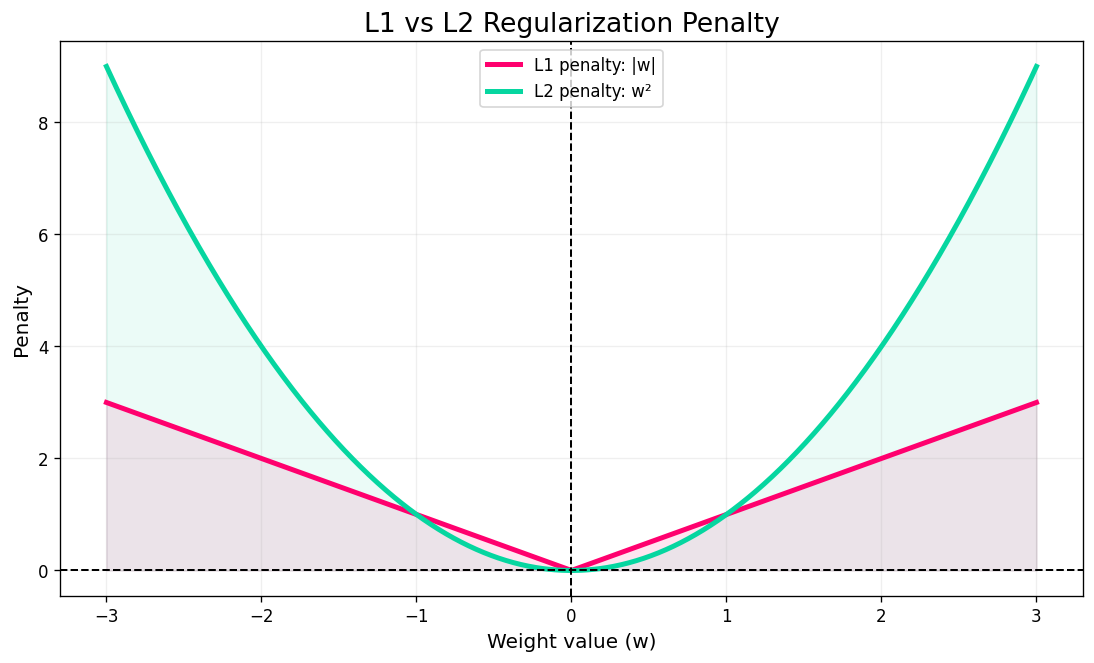

In [15]:
w = np.linspace(-3, 3, 1000)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    w,
    np.abs(w),
    color=COLORS["no_reg"],
    linewidth=3,
    label="L1 penalty: |w|"
)

ax.plot(
    w,
    w**2,
    color=COLORS["l2"],
    linewidth=3,
    label="L2 penalty: w²"
)

ax.fill_between(
    w,
    np.abs(w),
    alpha=0.10,
    color=COLORS["no_reg"]
)

ax.fill_between(
    w,
    w**2,
    alpha=0.08,
    color=COLORS["l2"]
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)

ax.set_title("L1 vs L2 Regularization Penalty")
ax.set_xlabel("Weight value (w)")
ax.set_ylabel("Penalty")
ax.legend()
ax.grid(alpha=0.20)

plt.show()

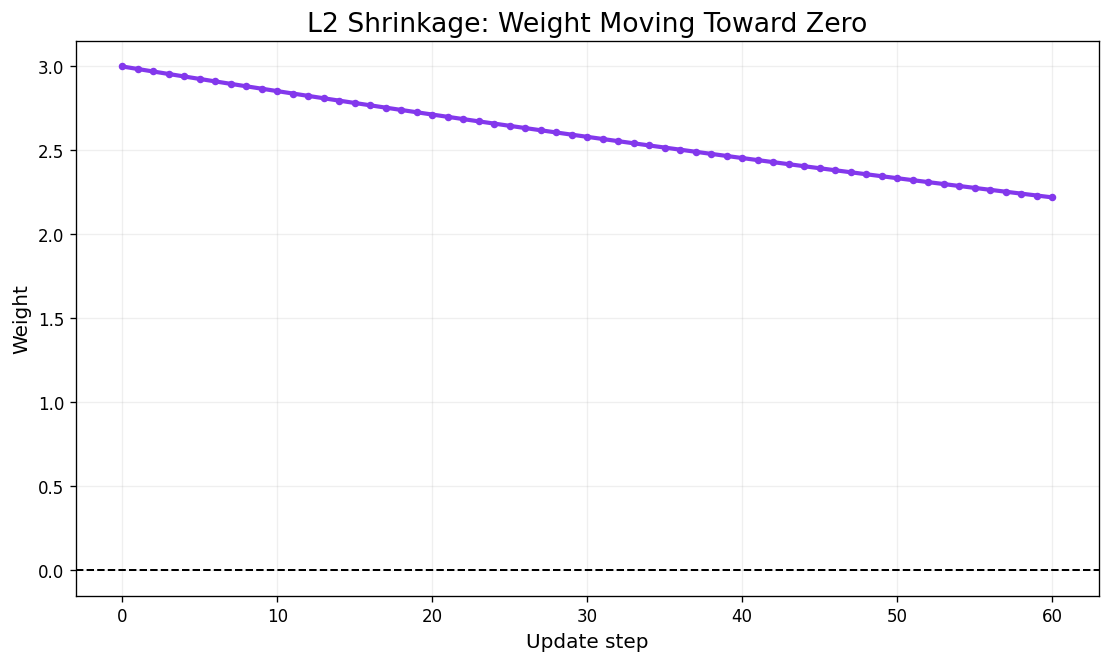

In [16]:
eta = 0.05
lambda_demo = 0.10
steps = 60

w = 3.0
weight_history = [w]

for _ in range(steps):
    grad_reg = lambda_demo * w
    w = w - eta * grad_reg
    weight_history.append(w)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    weight_history,
    marker="o",
    markersize=3.5,
    linewidth=2.5,
    color=COLORS["purple"]
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_title("L2 Shrinkage: Weight Moving Toward Zero")
ax.set_xlabel("Update step")
ax.set_ylabel("Weight")
ax.grid(alpha=0.20)

plt.show()

In [17]:
results = pd.DataFrame([
    evaluate_model(baseline, X_test, y_test, "No Regularization"),
    evaluate_model(model_l1, X_test, y_test, "L1"),
    evaluate_model(model_l2, X_test, y_test, "L2"),
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1,Log Loss,Σ|w|,Σw²,Near-zero weights (%)
0,No Regularization,0.896,0.8889,0.9032,0.8960,0.4749,5144.918945,5272.942383,3.7214
1,L1,0.912,0.9180,0.9032,0.9106,0.1626,91.473198,146.087799,99.0756
2,L2,0.920,0.9194,0.9194,0.9194,0.1930,254.932297,383.229309,88.2335


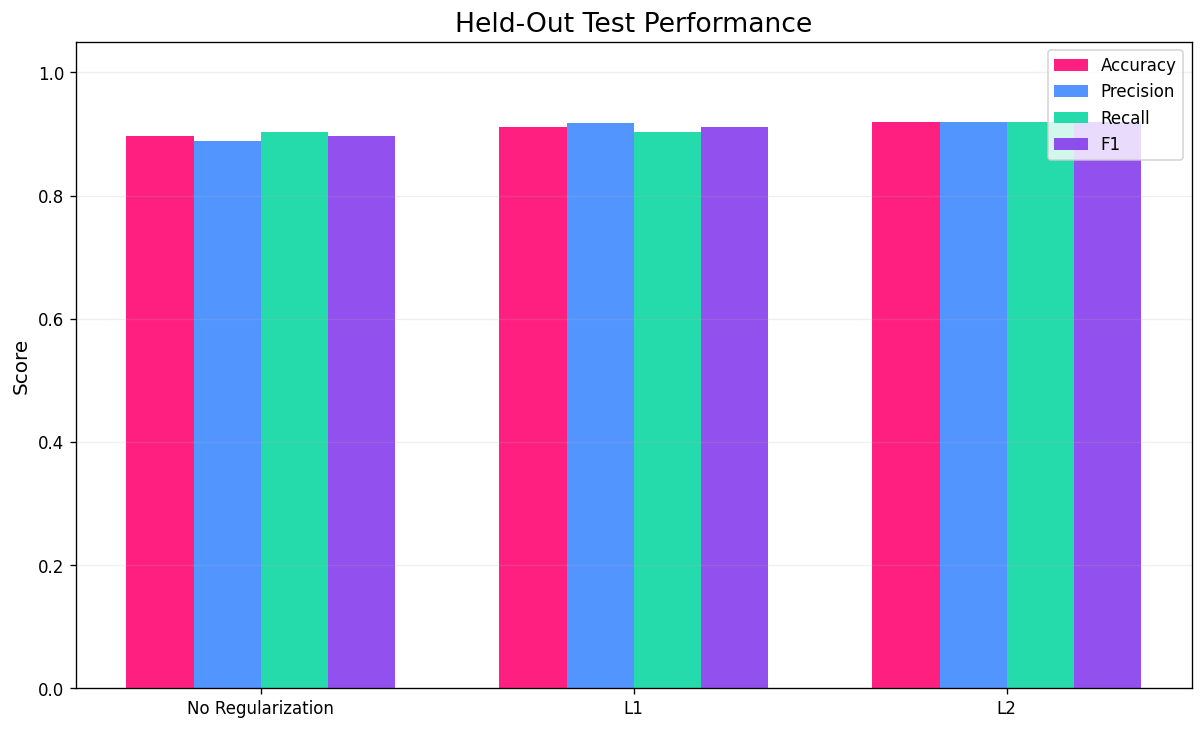

In [18]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
metric_colors = ["#FF006E", "#3A86FF", "#06D6A0", "#8338EC"]

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(results["Model"]))
width = 0.18

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    values = results[metric].values

    ax.bar(
        x + (i - 1.5) * width,
        values,
        width,
        color=color,
        alpha=0.88,
        label=metric
    )

ax.set_xticks(x)
ax.set_xticklabels(results["Model"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Held-Out Test Performance")
ax.legend()
ax.grid(axis="y", alpha=0.20)

plt.show()

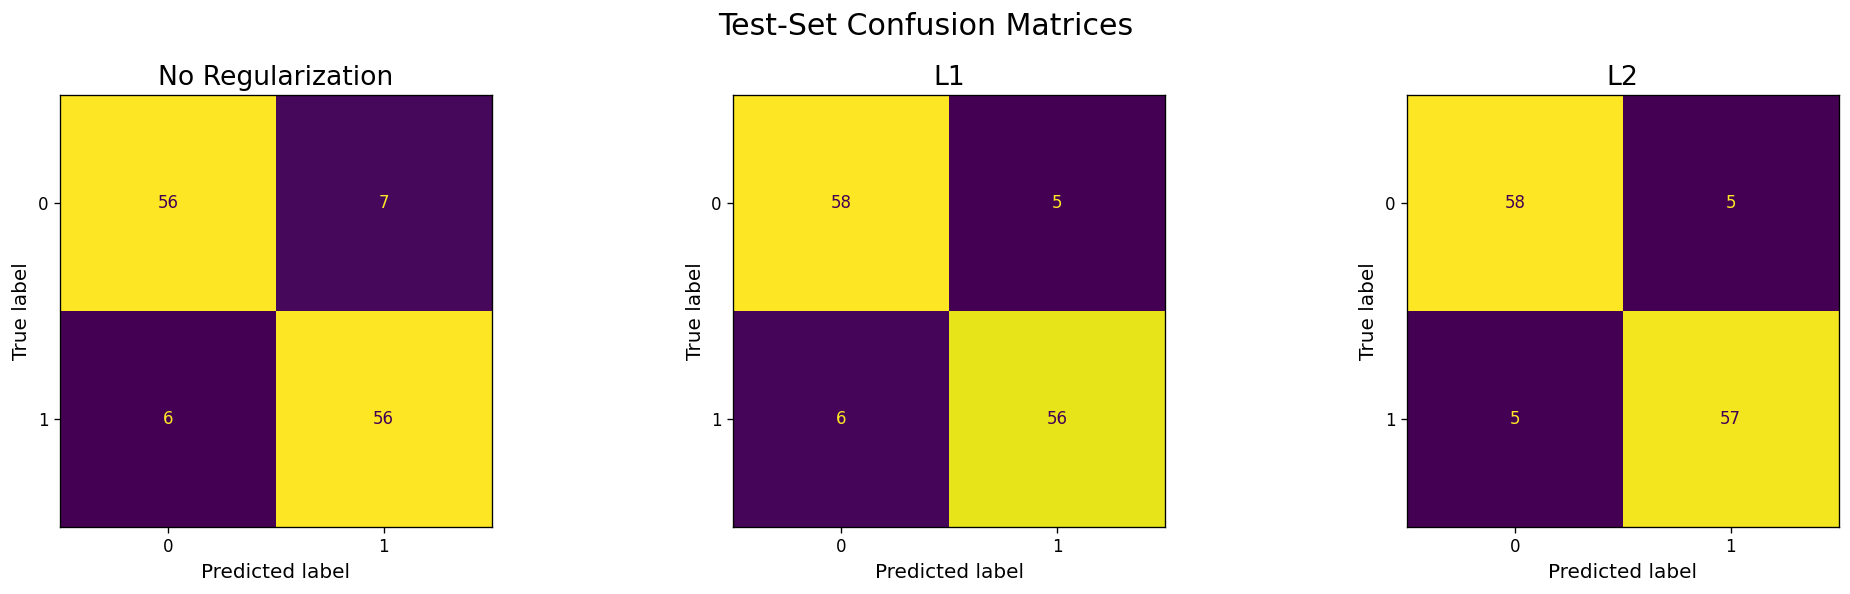

In [19]:
model_dict = {
    "No Regularization": baseline,
    "L1": model_l1,
    "L2": model_l2,
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, model_dict.items()):
    probs = model.predict(X_test, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=ax,
        cmap="viridis",
        colorbar=False
    )

    ax.set_title(name)

fig.suptitle("Test-Set Confusion Matrices", fontsize=18)
plt.tight_layout()
plt.show()

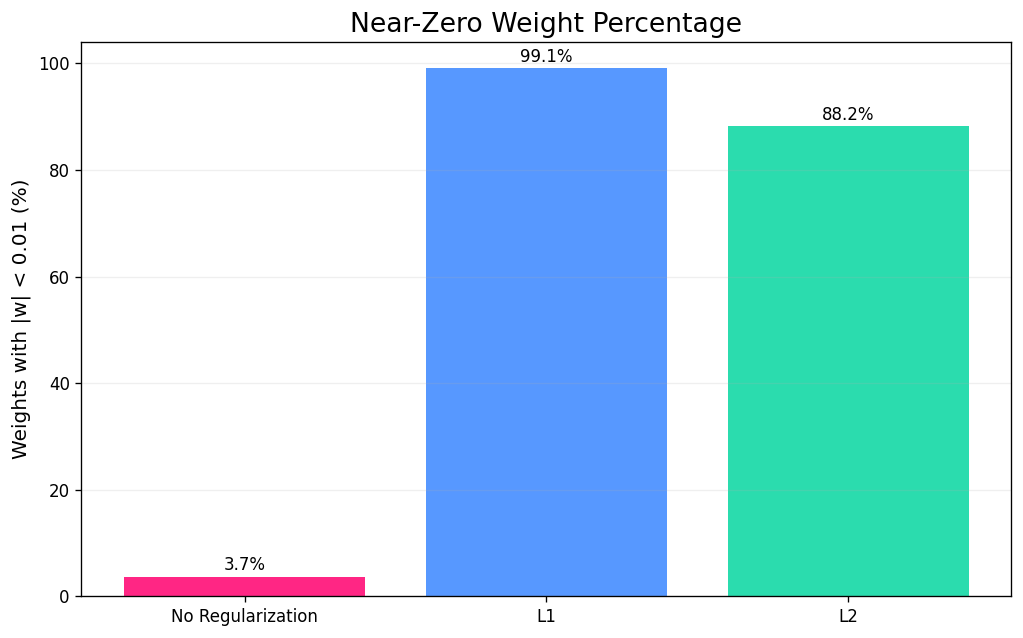

In [20]:
sparsity_values = results["Near-zero weights (%)"].values

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    results["Model"],
    sparsity_values,
    color=[COLORS["no_reg"], COLORS["l1"], COLORS["l2"]],
    alpha=0.85
)

ax.set_title("Near-Zero Weight Percentage")
ax.set_ylabel("Weights with |w| < 0.01 (%)")
ax.grid(axis="y", alpha=0.20)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [21]:
lambda_values = [0.0, 1e-5, 1e-4, 5e-4, 1e-3, 3e-3, 1e-2]

lambda_rows = []

for lam in lambda_values:

    model = build_model(
        reg_type="l2",
        lambda_value=lam
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=250,
        batch_size=32,
        validation_split=0.25,
        verbose=0,
        shuffle=True
    )

    prob = model.predict(X_test, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    lambda_rows.append({
        "lambda": lam,
        "test_accuracy": accuracy_score(y_test, pred),
        "best_val_accuracy": np.max(history.history["val_accuracy"]),
        "sum_squared_weights": l2_weight_sum(model),
        "near_zero_%": near_zero_percentage(model),
    })

lambda_df = pd.DataFrame(lambda_rows)
lambda_df.round(4)

,lambda,test_accuracy,best_val_accuracy,sum_squared_weights,near_zero_%
0,0.0000,0.928,0.9468,3998.451172,3.6438
1,0.0000,0.904,0.9574,969.690674,41.9549
2,0.0001,0.912,0.9574,294.270508,60.9494
3,0.0005,0.920,0.9468,183.039001,76.7593
4,0.0010,0.920,0.9574,179.934402,75.9125
5,0.0030,0.912,0.9574,208.987198,84.8223
6,0.0100,0.920,0.9574,384.735596,91.9788


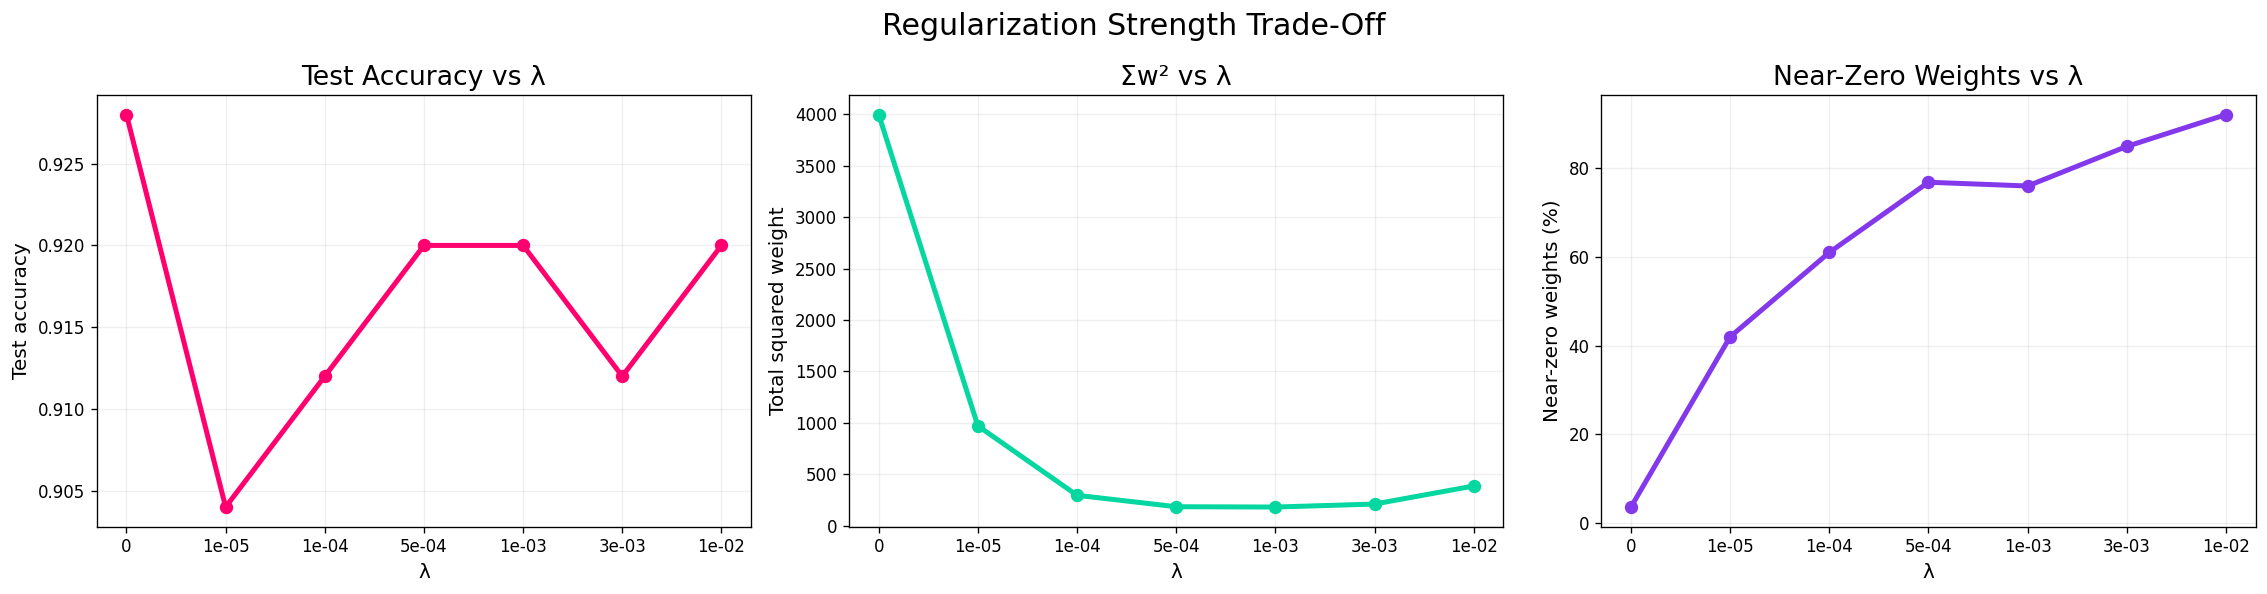

In [22]:
labels = [
    "0" if x == 0 else f"{x:.0e}"
    for x in lambda_df["lambda"]
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(
    labels,
    lambda_df["test_accuracy"],
    marker="o",
    linewidth=3,
    markersize=7,
    color=COLORS["no_reg"]
)
axes[0].set_title("Test Accuracy vs λ")
axes[0].set_xlabel("λ")
axes[0].set_ylabel("Test accuracy")
axes[0].grid(alpha=0.20)

axes[1].plot(
    labels,
    lambda_df["sum_squared_weights"],
    marker="o",
    linewidth=3,
    markersize=7,
    color=COLORS["l2"]
)
axes[1].set_title("Σw² vs λ")
axes[1].set_xlabel("λ")
axes[1].set_ylabel("Total squared weight")
axes[1].grid(alpha=0.20)

axes[2].plot(
    labels,
    lambda_df["near_zero_%"],
    marker="o",
    linewidth=3,
    markersize=7,
    color=COLORS["purple"]
)
axes[2].set_title("Near-Zero Weights vs λ")
axes[2].set_xlabel("λ")
axes[2].set_ylabel("Near-zero weights (%)")
axes[2].grid(alpha=0.20)

fig.suptitle("Regularization Strength Trade-Off", fontsize=18)
plt.tight_layout()
plt.show()

In [23]:
gap_rows = []

for name, history in [
    ("No Regularization", history_baseline),
    ("L1", history_l1),
    ("L2", history_l2),
]:
    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    gap_rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Generalization Gap": train_acc - val_acc,
    })

gap_df = pd.DataFrame(gap_rows)
gap_df.round(4)

,Model,Train Accuracy,Validation Accuracy,Generalization Gap
0,No Regularization,0.9822,0.8936,0.0886
1,L1,0.9395,0.9362,0.0033
2,L2,0.9537,0.9362,0.0176


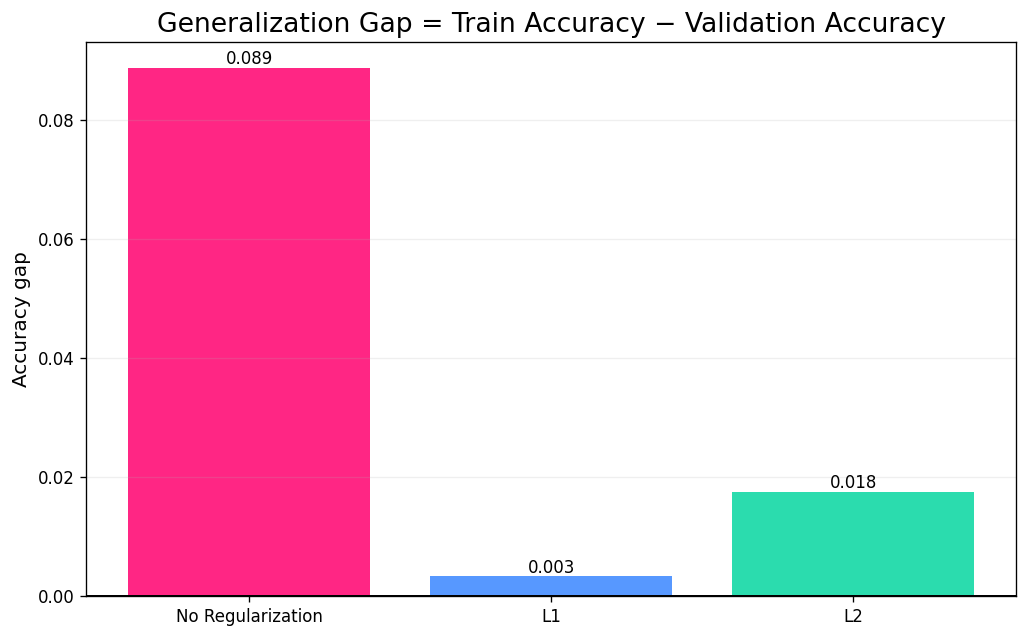

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    gap_df["Model"],
    gap_df["Generalization Gap"],
    color=[COLORS["no_reg"], COLORS["l1"], COLORS["l2"]],
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=1.2)
ax.set_title("Generalization Gap = Train Accuracy − Validation Accuracy")
ax.set_ylabel("Accuracy gap")
ax.grid(axis="y", alpha=0.20)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.show()